<a href="https://colab.research.google.com/github/DaeYejun2/PyTorch/blob/main/Wafer_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("qingyi/wm811k-wafer-map")

print("Path to dataset files:", path)

100%|██████████| 149M/149M [00:00<00:00, 226MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

path = "/root/.cache/kagglehub/datasets/qingyi/wm811k-wafer-map/versions/1"
file_path = os.path.join(path, "LSWMD.pkl")

df = pd.read_pickle(file_path)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB
None


In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
df.drop(['waferIndex', 'lotName', 'dieSize'], axis=1)

# failureType과 fullCorpus를 문자열/숫자로 변환하여 다루기 쉽게 만들기
# (원본은 리스트나 특수 객체 형태일 수 있음)
df['failureType'] = df['failureType'].astype(str)

# 3. 데이터 분포 확인
print("결함 패턴별 데이터 개수:")
print(df['failureType'].value_counts())

In [ ]:
# 문자열 정리 함수
def clean_label(x):
  x = x.replace('[', '').replace(']','').replace("'","")
  if x == "": return "unknown" # 비어있는 [] 처리
  return x

df['failureType'] = df['failureType'].apply(clean_label)

# unknown 데이터는 학습에서 제외 (패턴을 알 수 없기 때문)
df = df[df['failureType'] != 'unknown'].reset_index(drop=True)

# 레이블을 숫자로 변환
mapping_type = {
    'none': 0, 'Edge-Ring': 1, 'Edge-Loc': 2, 'Center': 3,
    'Loc': 4, 'Scratch': 5, 'Random': 6, 'Donut': 7, 'Near-full': 8
}
df['label'] = df['failureType'].map(mapping_type)

# 정제 후 데이터 분포
print(df['failureType'].value_counts())

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(12,12))
ax = ax.ravel() # 다차원 배열을 1차원 배열로

labels = ['none', 'Edge-Ring', 'Edge-Loc', 'Center', 'Loc', 'Scratch', 'Random', 'Donut', 'Near-full']

for i, label in enumerate(labels):
  # 해당 라벨의 첫 번째 행 추출
  subset = df[df['failureType'] == label].iloc[0]
  ax[i].imshow(subset['waferMap'], cmap='inferno')
  ax[i].set_title(f"{label} ({subset['waferMap'].shape})")
  ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import cv2

def resize_wafer(maps):
  # 모든 웨이퍼 맵 리사이징
  return cv2.resize(maps, dsize=(64,64), interpolation=cv2.INTER_NEAREST)

# 이미지 리사이징 적용
df['waferMap_resized'] = df['waferMap'].apply(resize_wafer)

# 모델 입력을 위한데이터 형태로 변환 (N, H, W)
X = np.stack(df['waferMap_resized'].values)
y = df['label'].values

# 채널 차원 추가 (N, H, W) -> (N, H, W, 1)
# ResNet을 위해 추후 (N, 3, H, W)로 바꿀 예정
X = X[:, :, :, np.newaxis]

print(f"전처리된 데이터 형태: {X.shape}") # (데이터 개수, 64,64,1)
print(f"전처리된 레이블 형태: {y.shape}")

In [ ]:
from sklearn.model_selection import train_test_split

# 1. 학습과 테스트 데이터를 나눠준다. (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. 다시 학습 데이터를 학습과 검증으로 나눈다.
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

print(f"학습 데이터 형태: {X_train.shape}, 라벨 개수: {len(np.unique(y_train))}")
print(f"검증 데이터 형태: {X_val.shape}")
print(f"테스트 데이터 형태: {X_test.shape}")

In [ ]:
import torch
from torchvision import transforms

def augment_data(X_data, y_data):
  X_augmented = []
  y_augmented = []

  # 90도씩 회전 및 좌우 반전 조합
  for i in range(len(X_data)):
    img = X_data[i]
    label = y_data[i]

    # 정상(none)은 너무 많으므로 증강 제외
    if label == 0:
      X_augmented.append(img)
      y_augmented.append(label)
      continue

    # 결함 데이터는 8가지 변형 생성 (원본+3번 회전) x (좌우 반전 여부)
    for r in [0,1,2,3]: # 0,90,180,270 도
      rotated = np.rot90(img, k=r)
      X_augmented.append(rotated)
      y_augmented.append(label)

      flipped = np.fliplr(rotated) # 좌우 반전
      X_augmented.append(flipped)
      y_augmented.append(label)

  return np.array(X_augmented), np.array(y_augmented)

# 학습 데이터에만 증강 적용
X_train_aug, y_train_aug = augment_data(X_train, y_train)

print(f"증강 전 학습 데이터 수: {len(X_train)}")
print(f"증강 후 학습 데이터 수: {len(X_train_aug)}")
print("증강 후 라벨별 분포:")
unique, counts = np.unique(y_train_aug, return_counts=True)
print(dict(zip(unique, counts)))

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models

# 데이터를 PyTorch 텐서로 변환 (N,H,W,C) -> (N,C,H,W)
def to_tensor(X, y):
  # ResNet을 위해 채널을 3개로 복제 (1채널->3채널)
  X_tensor = torch.from_numpy(X).permute(0,3,1,2).float()
  X_tensor = X_tensor.repeat(1,3,1,1) # (N.3.64.64)
  y_tensor = torch.from_numpy(y).long()
  return TensorDataset(X_tensor, y_tensor)

train_dataset = to_tensor(X_train_aug, y_train_aug)
val_dataset = to_tensor(X_val, y_val)
test_dataset = to_tensor(X_test, y_test)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=None) # 사전 학습된 가중치 없이 초기화

# 마지막 출력 레이어를 클래스 개수(9개)에 맞게 수정
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 9)

model = model.to(device)

In [16]:
import torch.optim as optim

# 손실 함수 (다중 클래스 분류)
criterion = nn.CrossEntropyLoss()

# 2. 최적화 도구 (Adam: 학습률을 스스로 조절하며 빠르게 수렴)
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
history = {'train_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0

  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad() # 기울기 초기화
    outputs = model(inputs) # 모델 예측
    loss = criterion(outputs, labels) # 오차 계산
    loss.backward() # 역전파
    optimizer.step() # 가중치 업데이트

    running_loss += loss.item() * inputs.size(0)

  epoch_loss = running_loss / len(train_loader.dataset)
  history['train_loss'].append(epoch_loss)

  # 평가
  model.eval()
  correct, total = 0, 0
  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  val_acc = 100 * correct / total
  history['val_acc'].append(val_acc)
  print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}%")


Epoch [1/10] Loss: 0.0274 | Val Acc: 97.32%
Epoch [2/10] Loss: 0.0222 | Val Acc: 97.40%
Epoch [3/10] Loss: 0.0190 | Val Acc: 97.43%
Epoch [4/10] Loss: 0.0170 | Val Acc: 97.42%
Epoch [5/10] Loss: 0.0156 | Val Acc: 97.46%
Epoch [6/10] Loss: 0.0137 | Val Acc: 97.36%
Epoch [7/10] Loss: 0.0135 | Val Acc: 97.34%
Epoch [8/10] Loss: 0.0125 | Val Acc: 97.02%
Epoch [9/10] Loss: 0.0114 | Val Acc: 97.24%
Epoch [10/10] Loss: 0.0109 | Val Acc: 97.33%


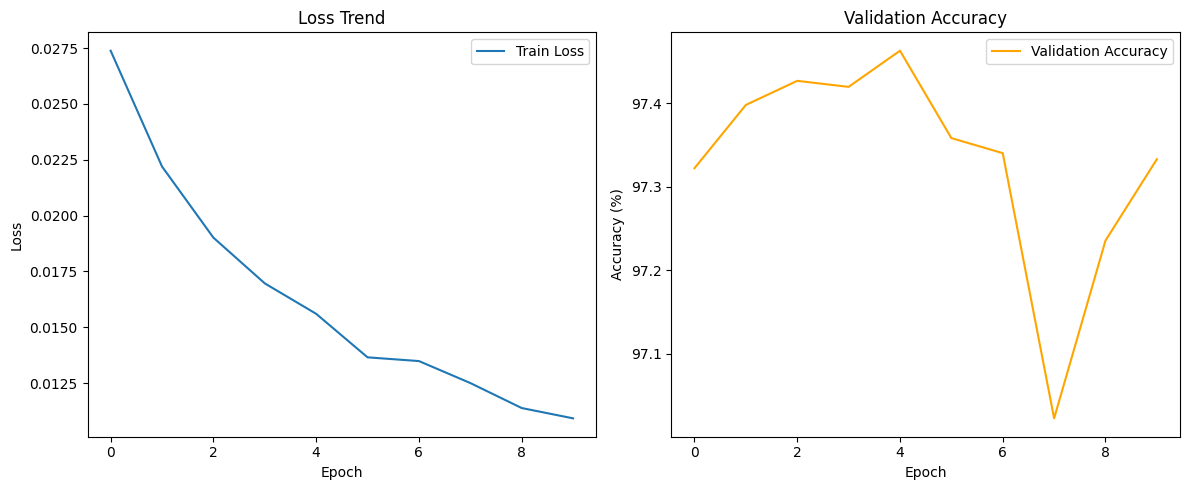

In [17]:
plt.figure(figsize=(12,5))

# Loss 그래프
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='Train Loss')
plt.title('Loss Trend')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프
plt.subplot(1,2,2)
plt.plot(history['val_acc'], label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

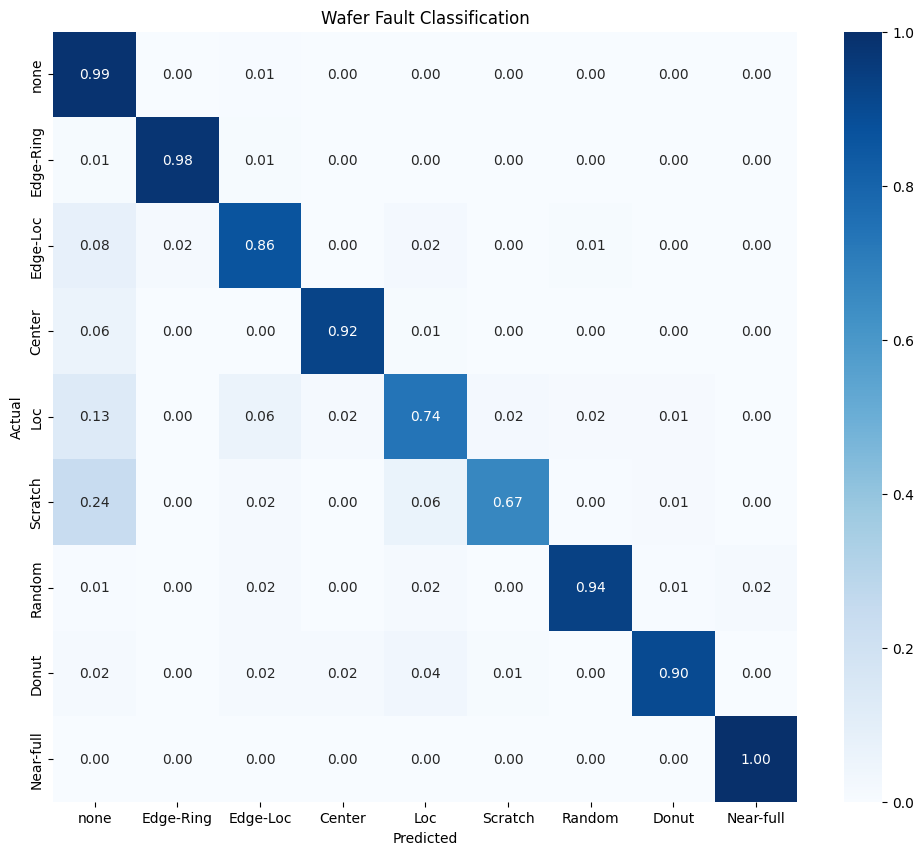

              precision    recall  f1-score   support

        none       0.99      0.99      0.99     29486
   Edge-Ring       0.97      0.98      0.98      1936
    Edge-Loc       0.79      0.86      0.82      1038
      Center       0.91      0.92      0.91       859
         Loc       0.78      0.74      0.76       718
     Scratch       0.67      0.67      0.67       239
      Random       0.81      0.94      0.87       173
       Donut       0.87      0.90      0.88       111
   Near-full       0.83      1.00      0.91        30

    accuracy                           0.97     34590
   macro avg       0.85      0.89      0.87     34590
weighted avg       0.97      0.97      0.97     34590



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

target_names = ['none', 'Edge-Ring', 'Edge-Loc', 'Center', 'Loc', 'Scratch', 'Random', 'Donut', 'Near-full']

# 테스트 데이터 평가
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
  for inputs, batch_labels in test_dataset:
    # 개별 데이터를 배치 형태(1, 3, 64, 64)로 변환하여 예측
    inputs = inputs.unsqueeze(0).to(device)
    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)

    y_true.append(batch_labels.item())
    y_pred.append(predicted.item())

# 혼동 행렬 시각화
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12,10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Wafer Fault Classification')
plt.show()

print(classification_report(y_true, y_pred, target_names=target_names))